In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt    #导入画图工具
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
#设置中文显示
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False

In [3]:
#读取文件
data = pd.read_csv("housing.csv")

In [4]:
data = data.select_dtypes(include=[np.number])  #只留数值，删掉所有文本列

In [5]:
#检查一下是否读取成功
print("文件读取成功！数据形状：", data.shape)

文件读取成功！数据形状： (20640, 9)


In [6]:
data.rename(columns={'median_house_value': '房价'}, inplace=True)
data = data.dropna()  # 处理缺失值

In [7]:
#构造特征、标签
X = data.drop('房价',axis=1)
y = data['房价']

In [8]:
#简单数据查看
print("数据集前5行:")
print(data.head())
print('\n数据基本信息：')
print(data.describe())

数据集前5行:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income        房价  
0       322.0       126.0         8.3252  452600.0  
1      2401.0      1138.0         8.3014  358500.0  
2       496.0       177.0         7.2574  352100.0  
3       558.0       219.0         5.6431  341300.0  
4       565.0       259.0         3.8462  342200.0  

数据基本信息：
          longitude      latitude  housing_median_age   total_rooms  \
count  20433.000000  20433.000000        20433.000000  20433.000000   
mean    -119.570689     35.633221           28.633094   2636.504233   
s

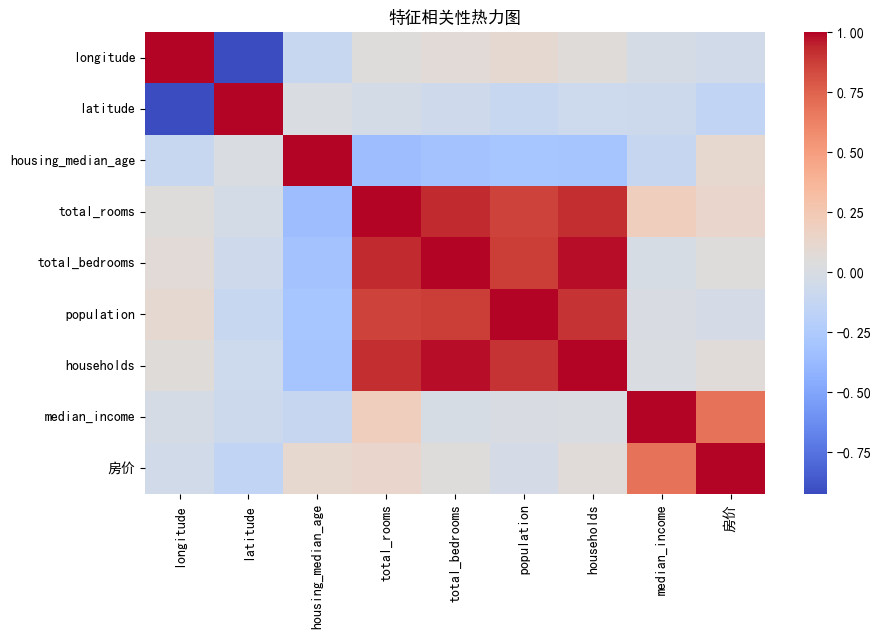

In [9]:
# 相关性热力图
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("特征相关性热力图")
plt.show()

In [10]:
#划分特征与标签
X=data.drop('房价',axis=1)     #大写X代表多列数据，小写y代表一列标签结果
y=data['房价']

In [11]:
#划分训练集、测试集
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2026)

In [12]:
#检查X_train的数据类型
print(X_train.dtypes)

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
dtype: object


In [13]:
class SimpleLinearRegression:
    #初始化
    def __init__(self):
        self.w=None    #权重
        self.b=None    #偏置
     #训练模型
    def fit(self,x_data,y_data):
        #转为numpy数组
        x=np.array(x_data)
        y=np.array(y_data)
        ones=np.ones((x.shape[0],1))
        x_new=np.hstack((ones,x))
        #方程求解
        xtx=np.dot(x_new.T,x_new)
        xty=np.dot(x_new.T,y)
        theta=np.dot(np.linalg.inv(xtx),xty)
        self.b=theta[0]
        self.w=theta[1:]
    #预测函数
    def predict(self,x_data):
        x=np.array(x_data)
        pre=self.b+np.dot(x,self.w)
        return pre

In [15]:
#训练手写模型
model = SimpleLinearRegression()
model.fit(X_train,y_train)

In [16]:
#预测
y_train_pre = model.predict(X_train)
y_test_pre = model.predict(X_test)

In [17]:
#计算评价指标
print("==========无正则化回归结果==========")
print("训练集均方误差MSE：",mean_squared_error(y_train,y_train_pre))
print("测试集均方误差MSE：",mean_squared_error(y_test,y_test_pre))
print("测试集决定系数R2：",r2_score(y_test,y_test_pre))

==========无正则化回归结果==========
训练集均方误差MSE： 4831833032.335358
测试集均方误差MSE： 4885990047.934293
测试集决定系数R2： 0.6296646902358637


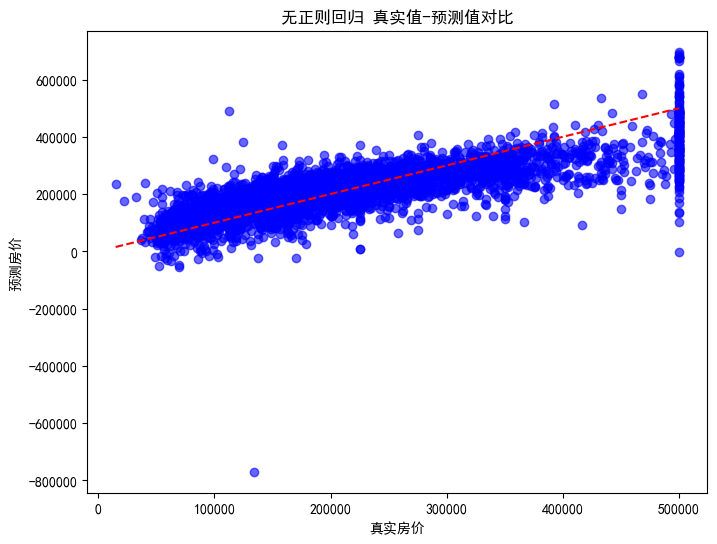

In [18]:
#真实值vs预测值绘图
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_test_pre,color='blue',alpha=0.6)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel("真实房价")
plt.ylabel("预测房价")
plt.title("无正则回归 真实值-预测值对比")
plt.show()